In [1]:
from utils import calcular_similaridade_sliding

/home/arthur/anaconda3/envs/qwen3-env2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /home/arthur/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/arthur/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
import pandas as pd
df = pd.read_parquet("/home/arthur/nlp/repo/simplification/med-simple-docs/bulas_all_v2.parquet")
similarities = calcular_similaridade_sliding(df)

100%|██████████| 30/30 [00:00<00:00, 30.03it/s]


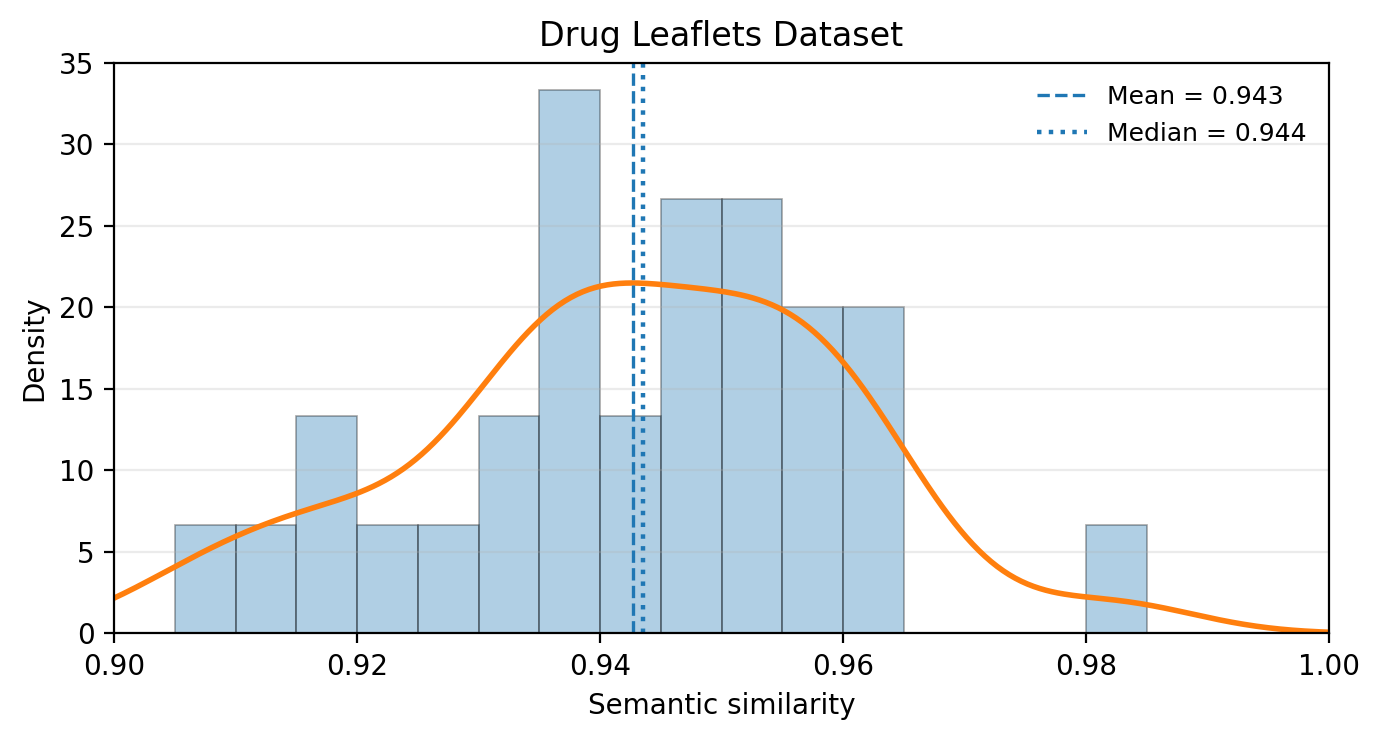

In [7]:
# Jupyter Notebook cell
# Plot the distribution of semantic similarity scores (values in [0, 1])
# Suitable for an academic NLP paper (clean histogram + KDE + summary stats).

import numpy as np
import matplotlib.pyplot as plt

def plot_similarity_distribution(similarities, bins=30, title="Semantic Similarity Distribution"):
    """
    similarities: list/array of floats in [0, 1]
    bins: number of histogram bins
    """
    sims = np.asarray(similarities, dtype=float)
    sims = sims[np.isfinite(sims)]  # drop NaN/inf if any

    if sims.size == 0:
        raise ValueError("No valid similarity values to plot.")

    # Clip to [0, 1] (optional safety)
    sims = np.clip(sims, 0.0, 1.0)

    # Simple Gaussian KDE implemented with numpy (no seaborn/scipy needed)
    def gaussian_kde_1d(x, grid, bandwidth=None):
        x = np.asarray(x)
        n = x.size
        if n < 2:
            return np.zeros_like(grid)

        # Silverman's rule of thumb for bandwidth
        std = np.std(x, ddof=1)
        iqr = np.subtract(*np.percentile(x, [75, 25]))
        sigma = min(std, iqr / 1.349) if (std > 0 and iqr > 0) else std
        if bandwidth is None:
            bandwidth = 0.9 * sigma * (n ** (-1/5)) if sigma > 0 else 0.05
        bandwidth = max(bandwidth, 1e-3)

        diff = (grid[:, None] - x[None, :]) / bandwidth
        dens = np.exp(-0.5 * diff**2).sum(axis=1) / (n * bandwidth * np.sqrt(2*np.pi))
        return dens

    # Stats
    mean = float(np.mean(sims))
    median = float(np.median(sims))
    std = float(np.std(sims, ddof=1)) if sims.size > 1 else 0.0
    q25, q75 = np.percentile(sims, [25, 75])

    xmin = 0.9
    xmax = 1.0

    fig, ax = plt.subplots(figsize=(7.0, 3.8), dpi=200)

    # Histogram limitado ao intervalo desejado
    ax.hist(
        sims,
        bins=bins,
        range=(xmin, xmax),
        density=True,
        alpha=0.35,
        edgecolor="black",
        linewidth=0.6
    )

    # KDE apenas no intervalo
    grid = np.linspace(xmin, xmax, 400)
    kde = gaussian_kde_1d(sims, grid)
    ax.plot(grid, kde, linewidth=2.0)

    # Linhas de referência
    ax.axvline(mean, linestyle="--", linewidth=1.2, label=f"Mean = {mean:.3f}")
    ax.axvline(median, linestyle=":", linewidth=1.6, label=f"Median = {median:.3f}")

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel("Semantic similarity")
    ax.set_ylabel("Density")
    #ax.set_title("Distribution of Semantic Similarity Scores")
    ax.set_title("Drug Leaflets Dataset")
    ax.legend(frameon=False, fontsize=9)
    ax.grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

# ----------------------------
# Example usage (replace with your list)
#similarities = [0.91, 0.87, 0.76, 0.82, 0.94, 0.68, 0.73, 0.88, 0.79, 0.91, 0.85]
plot_similarity_distribution(similarities, bins=20, title="Distribution of Semantic Similarity Scores")


In [5]:
from utils import contar_caracteres, contar_palavras, legal_sentence_split, flesch_portugues
def count_sentences(text: str) -> int:
    """Conta o número de sentenças no texto."""
    return len(legal_sentence_split(text))

df["orig_chars"] = df["docs"].apply(contar_caracteres)
df["orig_words"] = df["docs"].apply(contar_palavras)
df["orig_sents"] = df["docs"].apply(count_sentences)
# Paraphrase
df["para_chars"] = df["rev1"].apply(contar_caracteres)
df["para_words"] = df["rev1"].apply(contar_palavras)
df["para_sents"] = df["rev1"].apply(count_sentences)

df["flesch_original"] = df["docs"].apply(flesch_portugues)
df["flesch_paraphrase"] = df["rev1"].apply(flesch_portugues)

print("Caracteres Orig: "+str(df["orig_chars"].mean()))
print("Words Orig: "+str(df["orig_words"].mean()))
print("Sentences Orig: "+str(df["orig_sents"].mean()))
print("Caracteres Rev1: "+str(df["para_chars"].mean()))
print("Words Rev1: "+str(df["para_words"].mean()))
print("Senteces Rev1: "+str(df["para_sents"].mean()))
print("Flesch Orig: "+str(df["flesch_original"].mean()))
print("Flesch Rev1: "+str(df["flesch_paraphrase"].mean()))

Caracteres Orig: 14124.066666666668
Words Orig: 2514.5
Sentences Orig: 139.0
Caracteres Rev1: 8189.033333333334
Words Rev1: 1561.2333333333333
Senteces Rev1: 109.7
Flesch Orig: 7.286666666666668
Flesch Rev1: 26.606333333333332


In [3]:
from utils import contar_caracteres, contar_palavras, legal_sentence_split, flesch_portugues
def count_sentences(text: str) -> int:
    """Conta o número de sentenças no texto."""
    return len(legal_sentence_split(text))

df["orig_chars"] = df["docs"].apply(contar_caracteres)
df["orig_words"] = df["docs"].apply(contar_palavras)
df["orig_sents"] = df["docs"].apply(count_sentences)
# Paraphrase
df["para_chars"] = df["rev1"].apply(contar_caracteres)
df["para_words"] = df["rev1"].apply(contar_palavras)
df["para_sents"] = df["rev1"].apply(count_sentences)

df["flesch_original"] = df["docs"].apply(flesch_portugues)
df["flesch_paraphrase"] = df["rev1"].apply(flesch_portugues)

print("Caracteres Orig: "+str(df["orig_chars"].mean()))
print("Words Orig: "+str(df["orig_words"].mean()))
print("Sentences Orig: "+str(df["orig_sents"].mean()))
print("Caracteres Rev1: "+str(df["para_chars"].mean()))
print("Words Rev1: "+str(df["para_words"].mean()))
print("Senteces Rev1: "+str(df["para_sents"].mean()))
print("Flesch Orig: "+str(df["flesch_original"].mean()))
print("Flesch Rev1: "+str(df["flesch_paraphrase"].mean()))

Caracteres Orig: 14124.066666666668
Words Orig: 2514.5
Sentences Orig: 139.0
Caracteres Rev1: 8242.1
Words Rev1: 1571.9
Senteces Rev1: 109.7
Flesch Orig: 7.286666666666668
Flesch Rev1: 26.519333333333336


Esse de cima é o v2!